In [1]:
from datetime import datetime, timedelta
import dukascopy_python
from dukascopy_python.instruments import INSTRUMENT_FX_MAJORS_EUR_USD
import pandas as pd



Data Retrieval

In [2]:
start = datetime(2025, 1, 1)
end = datetime(2025, 12, 31)

raw_ticks = dukascopy_python.fetch(
    instrument=INSTRUMENT_FX_MAJORS_EUR_USD,
    interval=dukascopy_python.INTERVAL_TICK,
    offer_side=dukascopy_python.OFFER_SIDE_BID,
    start=start,
    end=end,
)

print(f"Fetched {len(raw_ticks):,} ticks")
print(f"Columns: {list(raw_ticks.columns)}")
print(f"Range: {raw_ticks.index.min()} -> {raw_ticks.index.max()}")
raw_ticks.head()

INFO:DUKASCRIPT:current timestamp :2025-01-02T10:39:00.503000
INFO:DUKASCRIPT:current timestamp :2025-01-02T15:33:12.837000
INFO:DUKASCRIPT:current timestamp :2025-01-02T18:14:34.329000
INFO:DUKASCRIPT:current timestamp :2025-01-03T09:07:14.322000
INFO:DUKASCRIPT:current timestamp :2025-01-03T16:10:17.742000
INFO:DUKASCRIPT:current timestamp :2025-01-06T03:02:52.779000
INFO:DUKASCRIPT:current timestamp :2025-01-06T12:11:22.580000
INFO:DUKASCRIPT:current timestamp :2025-01-06T14:46:41.897000
INFO:DUKASCRIPT:current timestamp :2025-01-06T16:56:29.110000
INFO:DUKASCRIPT:current timestamp :2025-01-07T04:31:09.192000
INFO:DUKASCRIPT:current timestamp :2025-01-07T12:27:15.148000
INFO:DUKASCRIPT:current timestamp :2025-01-07T16:35:03.113000
INFO:DUKASCRIPT:current timestamp :2025-01-07T21:18:33.660000
INFO:DUKASCRIPT:current timestamp :2025-01-08T10:12:59.053000
INFO:DUKASCRIPT:current timestamp :2025-01-08T14:08:05.821000
INFO:DUKASCRIPT:current timestamp :2025-01-08T17:21:40.334000
INFO:DUK

Fetched 23,409,558 ticks
Columns: ['bidPrice', 'askPrice', 'bidVolume', 'askVolume']
Range: 2025-01-01 22:00:14.647000+00:00 -> 2025-12-30 22:59:47.863000+00:00


,bidPrice,askPrice,bidVolume,askVolume
timestamp,,,,
2025-01-01 22:00:14.647000+00:00,1.03503,1.03591,4.50,4.50
2025-01-01 22:00:14.949000+00:00,1.03510,1.03585,0.72,0.72
2025-01-01 22:00:19.212000+00:00,1.03514,1.03585,0.75,0.72
2025-01-01 22:02:34.026000+00:00,1.03514,1.03590,0.75,4.50
2025-01-01 22:04:01.734000+00:00,1.03514,1.03612,0.75,0.90


In [3]:
raw_ticks.index.dtype

datetime64[ns, UTC]

Mid price: $p_t = (\text{bid}_t + \text{ask}_t)/2$

In [4]:
raw_ticks['mid'] = (raw_ticks['bidPrice']+ raw_ticks['askPrice'])/2
raw_ticks['mid'].head()

timestamp
2025-01-01 22:00:14.647000+00:00    1.035470
2025-01-01 22:00:14.949000+00:00    1.035475
2025-01-01 22:00:19.212000+00:00    1.035495
2025-01-01 22:02:34.026000+00:00    1.035520
2025-01-01 22:04:01.734000+00:00    1.035630
Name: mid, dtype: float64

Tick volume: $v_t = \text{bidVolume}_t + \text{askVolume}_t$

In [5]:
raw_ticks['volume'] = raw_ticks['bidVolume'] + raw_ticks['askVolume']
raw_ticks['volume'].head()

timestamp
2025-01-01 22:00:14.647000+00:00    9.00
2025-01-01 22:00:14.949000+00:00    1.44
2025-01-01 22:00:19.212000+00:00    1.47
2025-01-01 22:02:34.026000+00:00    5.25
2025-01-01 22:04:01.734000+00:00    1.65
Name: volume, dtype: float64

In [6]:
fivemin_bars=raw_ticks.resample('5min').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )
fivemin_bars.head(5)

,open,high,low,close,vol,tick_count
timestamp,,,,,,
2025-01-01 22:00:00+00:00,1.035470,1.035630,1.035470,1.035485,36.21,9
2025-01-01 22:05:00+00:00,1.035520,1.035530,1.035185,1.035285,105.72,46
2025-01-01 22:10:00+00:00,1.035285,1.035305,1.035060,1.035225,60.42,25
2025-01-01 22:15:00+00:00,1.035295,1.035470,1.035250,1.035470,97.86,39
2025-01-01 22:20:00+00:00,1.035485,1.035510,1.035300,1.035425,134.10,22


In [48]:
tenmin_bars=raw_ticks.resample('10min').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )
    
tenmin_bars.head(10)

,open,high,low,close,vol,tick_count
timestamp,,,,,,
2025-01-01 22:00:00+00:00,1.035470,1.035630,1.035185,1.035285,141.930,55
2025-01-01 22:10:00+00:00,1.035285,1.035470,1.035060,1.035470,158.280,64
2025-01-01 22:20:00+00:00,1.035485,1.035630,1.035300,1.035615,240.030,60
2025-01-01 22:30:00+00:00,1.035610,1.035795,1.035605,1.035780,538.920,178
2025-01-01 22:40:00+00:00,1.035770,1.035795,1.035680,1.035735,1552.170,660
2025-01-01 22:50:00+00:00,1.035730,1.035830,1.035625,1.035665,649.650,306
2025-01-01 23:00:00+00:00,1.035660,1.035660,1.035145,1.035455,1626.589,417
2025-01-01 23:10:00+00:00,1.035445,1.035450,1.035295,1.035410,495.330,205
2025-01-01 23:20:00+00:00,1.035405,1.035405,1.035145,1.035155,861.330,276


In [7]:
onehour_bars = raw_ticks.resample('1h').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )
onehour_bars.head(5)

,open,high,low,close,vol,tick_count
timestamp,,,,,,
2025-01-01 22:00:00+00:00,1.035470,1.035830,1.035060,1.035665,3280.980,1323
2025-01-01 23:00:00+00:00,1.035660,1.035660,1.034650,1.035090,6610.249,1981
2025-01-02 00:00:00+00:00,1.035095,1.035655,1.034740,1.035215,9212.850,2059
2025-01-02 01:00:00+00:00,1.035220,1.036080,1.034430,1.035795,13172.940,3942
2025-01-02 02:00:00+00:00,1.035790,1.037130,1.035785,1.037105,7048.160,1627


In [8]:
sixhour_bars = raw_ticks.resample('6h').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )

In [9]:
eighthour_bars = raw_ticks.resample('8h').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )

In [10]:
import numpy as np
import pandas as pd

In [49]:
fivemin_bars['Y'] = np.log(fivemin_bars['close']/fivemin_bars['close'].shift(1)) 
# Yt is the return variable that has been used in the Paper. 
fivemin_bars['Y'].shape
tenmin_bars['Y'] = np.log(tenmin_bars['close'] / tenmin_bars['close'].shift(1))
tenmin_bars['Y'].head(10)
onehour_bars['Y'] = np.log(onehour_bars['close']/onehour_bars['close'].shift(1))
sixhour_bars['Y'] = np.log(sixhour_bars['close']/sixhour_bars['close'].shift(1)) 
eighthour_bars['Y'] = np.log(eighthour_bars['close']/eighthour_bars['close'].shift(1)) 






In [13]:
type(fivemin_bars['Y'])

pandas.core.series.Series

In [50]:
y5 = fivemin_bars['Y'].dropna()
y10 = tenmin_bars['Y'].dropna()
y1 = onehour_bars['Y'].dropna()
y6 = sixhour_bars['Y'].dropna()
y8 = eighthour_bars['Y'].dropna()


In [17]:
from scipy.stats import moment, skew, kurtosis


DESCRIPTIVE STATISTICS

In [18]:
def get_stats(series, name):
    s=series.dropna()
    return{ 'series': name,
        'mean': s.mean(),
        'variance': moment(s, moment=2),
        'm3': moment(s, moment=3),
        'm4': moment(s, moment=4),
        'm5': moment(s, moment=5),
        'm6': moment(s, moment=6),
        'skewness': skew(s),
        'kurtosis': kurtosis(s, fisher=False),
    }

In [51]:
results =[]
results.append(get_stats(fivemin_bars['Y'], 'Returns (5min)'))
results.append(get_stats(tenmin_bars['Y'], 'Returns (10min)'))
results.append(get_stats(onehour_bars['Y'], 'Returns (1h)'))
results.append(get_stats(sixhour_bars['Y'], 'Returns (6h)'))
results.append(get_stats(eighthour_bars['Y'], 'Returns (8h)'))

results.append(get_stats(fivemin_bars['vol'], 'volume5min'))
results.append(get_stats(tenmin_bars['vol'], 'volume10min'))
results.append(get_stats(onehour_bars['vol'], 'volume1h'))
results.append(get_stats(sixhour_bars['vol'], 'volume6h'))
results.append(get_stats(eighthour_bars['vol'], 'volume8h'))

results.append(get_stats(fivemin_bars['tick_count'], 'tick5min'))
results.append(get_stats(tenmin_bars['tick_count'], 'tick10min'))
results.append(get_stats(onehour_bars['tick_count'], 'tick1h'))
results.append(get_stats(sixhour_bars['tick_count'], 'tick6h'))
results.append(get_stats(eighthour_bars['tick_count'], 'tick8h'))


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

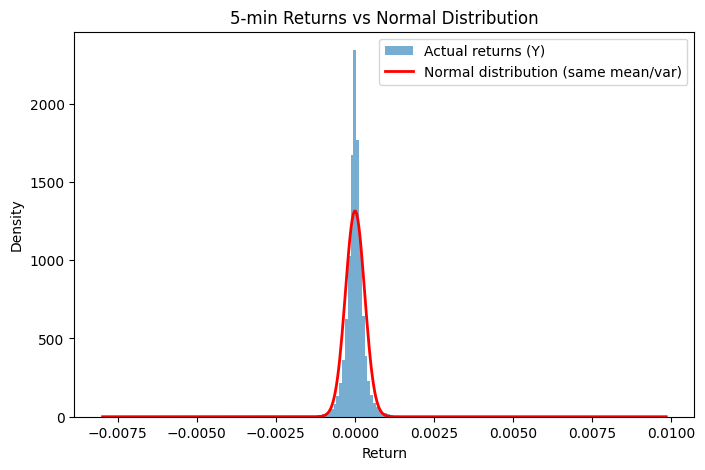

In [22]:
# Normal distribution with same mean/variance as our data
mu, sigma = y5.mean(), y5.std()
x_range = np.linspace(y5.min(), y5.max(), 500)
normal_curve = norm.pdf(x_range, mu, sigma)

plt.figure(figsize=(8,5))
plt.hist(y5, bins=200, density=True, alpha=0.6, label='Actual returns (Y)')
plt.plot(x_range, normal_curve, 'r-', linewidth=2, label='Normal distribution (same mean/var)')
plt.legend()
plt.title('5-min Returns vs Normal Distribution')
plt.xlabel('Return')
plt.ylabel('Density')
plt.show()



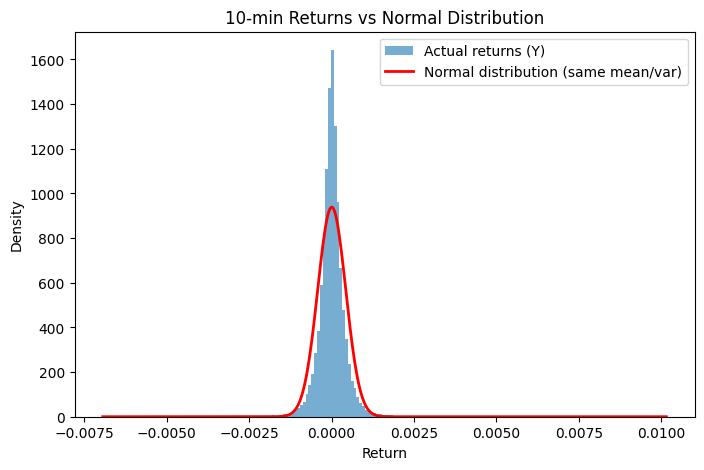

In [23]:
mu, sigma = y10.mean(), y10.std()
x_range = np.linspace(y10.min(), y10.max(), 500)
normal_curve = norm.pdf(x_range, mu, sigma)

plt.figure(figsize=(8,5))
plt.hist(y10, bins=200, density=True, alpha=0.6, label='Actual returns (Y)')
plt.plot(x_range, normal_curve, 'r-', linewidth=2, label='Normal distribution (same mean/var)')
plt.legend()
plt.title('10-min Returns vs Normal Distribution')
plt.xlabel('Return')
plt.ylabel('Density')
plt.show()

REGRESSION 
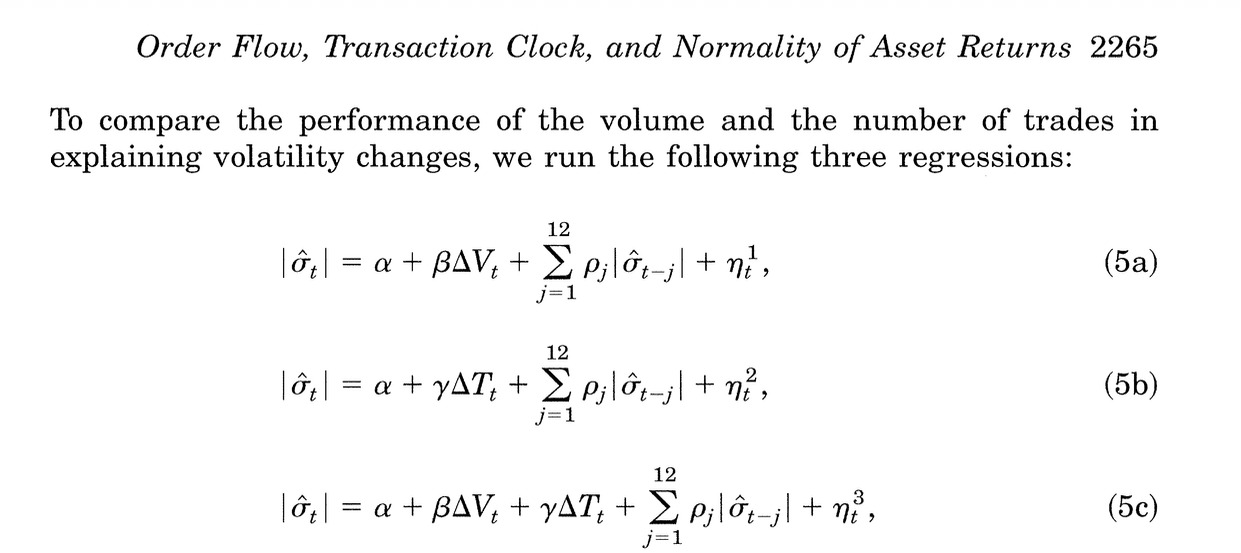

In [24]:
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg, gaussian_kde

In [53]:
def run_volatility_regressions(bars_df, label=""):
    y = bars_df['Y'].dropna()
    
    model = AutoReg(y, lags=12, old_names=False).fit()
    residuals = model.resid
    sigma_hat = np.sqrt(np.pi/2) * np.abs(residuals)
    
    delta_V = bars_df['vol'].diff()
    delta_T = bars_df['tick_count'].diff()
    
    reg_data = pd.DataFrame({'sigma_hat': sigma_hat})
    for lag in range(1, 13):
        reg_data[f'sigma_lag{lag}'] = reg_data['sigma_hat'].shift(lag)
    reg_data['delta_V'] = delta_V
    reg_data['delta_T'] = delta_T
    reg_data = reg_data.dropna()
    
    lag_cols = [f'sigma_lag{i}' for i in range(1, 13)]
    
    X_5a = sm.add_constant(reg_data[['delta_V'] + lag_cols])
    model_5a = sm.OLS(reg_data['sigma_hat'], X_5a).fit()
    
    X_5b = sm.add_constant(reg_data[['delta_T'] + lag_cols])
    model_5b = sm.OLS(reg_data['sigma_hat'], X_5b).fit()
    
    X_5c = sm.add_constant(reg_data[['delta_V', 'delta_T'] + lag_cols])
    model_5c = sm.OLS(reg_data['sigma_hat'], X_5c).fit()
    
    print(f"--- {label} ---")
    print("Adjusted R² (5a, volume only):", model_5a.rsquared_adj)
    print("Adjusted R² (5b, trade count only):", model_5b.rsquared_adj)
    print("Adjusted R² (5c, both):", model_5c.rsquared_adj)
    
    return model_5a, model_5b, model_5c, reg_data

In [54]:
def plot_kde(series, title, zero_filter=False, quantile_cutoff=0.99):
    s = series.dropna()
    if zero_filter:
        s = s[s > 0]
    
    n = len(s)
    sigma = s.std()
    h = sigma * (4/3)**(1/5) * n**(-1/5)#corrected silverman bandwidth
    bw_factor = h / sigma
    
    upper = s.quantile(quantile_cutoff)
    x_range = np.linspace(s.min(), upper, 500)
    density = gaussian_kde(s, bw_method=bw_factor)(x_range)
    
    plt.figure(figsize=(8,5))
    plt.plot(x_range, density)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel('Density')
    plt.show()

In [56]:
results = []
for bars, res_name in [(fivemin_bars, '5min'), (tenmin_bars, '10min'), (onehour_bars, '1h'), (sixhour_bars, '6h'), (eighthour_bars, '8h')]:
    results.append(get_stats(bars['Y'], f'Returns ({res_name})'))
    results.append(get_stats(bars['vol'], f'Volume ({res_name})'))
    results.append(get_stats(bars['tick_count'], f'Trade Count ({res_name})'))

table_I = pd.DataFrame(results)
table_I

,series,mean,variance,m3,m4,m5,m6,skewness,kurtosis
0,Returns (5min),0.000002,9.189119e-08,9.090209e-12,4.532401e-13,1.154913e-15,2.267718e-17,0.326335,53.676055
1,Volume (5min),719.684009,9.114694e+05,2.745985e+09,1.859312e+13,1.632576e+17,1.771744e+21,3.155623,22.380416
2,Trade Count (5min),223.894927,7.820919e+04,5.770980e+07,9.033894e+10,1.596049e+14,3.263277e+17,2.638535,14.769284
3,Returns (10min),0.000004,1.805830e-07,3.107532e-11,9.564919e-13,3.061902e-15,4.299840e-17,0.404949,29.331064
4,Volume (10min),1439.368017,3.471406e+06,1.915360e+10,2.330823e+14,3.524194e+18,6.481181e+22,2.961367,19.341866
5,Trade Count (10min),447.789854,3.005150e+05,4.176294e+08,1.242654e+12,4.111642e+15,1.574600e+19,2.535081,13.759983
6,Returns (1h),0.000024,9.979026e-07,5.819898e-10,1.648630e-11,5.879027e-14,1.157410e-15,0.583826,16.555679
7,Volume (1h),8636.208104,1.077577e+08,2.582429e+12,1.340280e+17,7.600664e+21,5.005511e+26,2.308639,11.542474
8,Trade Count (1h),2686.739125,9.563195e+06,6.266081e+10,9.292636e+14,1.443918e+19,2.588661e+23,2.118807,10.160916
9,Returns (6h),0.000129,5.850482e-06,6.793392e-09,2.304107e-10,9.927792e-13,2.030254e-14,0.480064,6.731616


In [58]:
run_volatility_regressions(fivemin_bars, label="5-min bars")
run_volatility_regressions(tenmin_bars, label="10-min bars")
run_volatility_regressions(onehour_bars, label="1 hour bars")
run_volatility_regressions(sixhour_bars, label="6 hour bars")
run_volatility_regressions(eighthour_bars, label="8 hour bars")

C:\Users\maria\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


--- 5-min bars ---
Adjusted R² (5a, volume only): 0.25893616203871916
Adjusted R² (5b, trade count only): 0.28565565553867633
Adjusted R² (5c, both): 0.28572422590381874
--- 10-min bars ---
Adjusted R² (5a, volume only): 0.2687517175664629
Adjusted R² (5b, trade count only): 0.2906160059550885
Adjusted R² (5c, both): 0.2906222037722337
--- 1 hour bars ---
Adjusted R² (5a, volume only): 0.2138053920424604
Adjusted R² (5b, trade count only): 0.23299972065357244
Adjusted R² (5c, both): 0.23292934673289833
--- 6 hour bars ---
Adjusted R² (5a, volume only): 0.15440174757077052
Adjusted R² (5b, trade count only): 0.1693000855732748
Adjusted R² (5c, both): 0.16935533839540162
--- 8 hour bars ---
Adjusted R² (5a, volume only): 0.10014230329057638
Adjusted R² (5b, trade count only): 0.11234531933038694
Adjusted R² (5c, both): 0.11334705476985496


C:\Users\maria\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\maria\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\maria\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\maria\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency in

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1b329683170>,
                            sigma_hat  sigma_lag1  sigma_lag2  sigma_lag3  \
 timestamp                                                                  
 2025-01-14 00:00:00+00:00   0.001425    0.007865    0.002144    0.003711   
 2025-01-14 08:00:00+00:00   0.004681    0.001425    0.007865    0.002144   
 2025-01-14 16:00:00+00:00   0.000649    0.004681    0.001425    0.007865   
 2025-01-15 00:00:00+00:00   0.000815    0.000649    0.004681    0.001425   
 2025-01-15 08:00:00+00:00   0.000543    0.000815    0.000649    0.004681   
 ...                              ...         ...         ...         ...   
 2025-12-29 08:00:00+00:00   0.001398    0.000558    0.000874    0.000452   
 2025-12-29 16:00:00+00:00   0.000373    0.001398    0.000558    0.000874   
 2025-12-30 00:00:00+00:00   0.000598    0.000373    0.001398    0.000558   
 2025-12-30 08:00:00+00:00   0.001379    0.000598    0.000373    0.0013

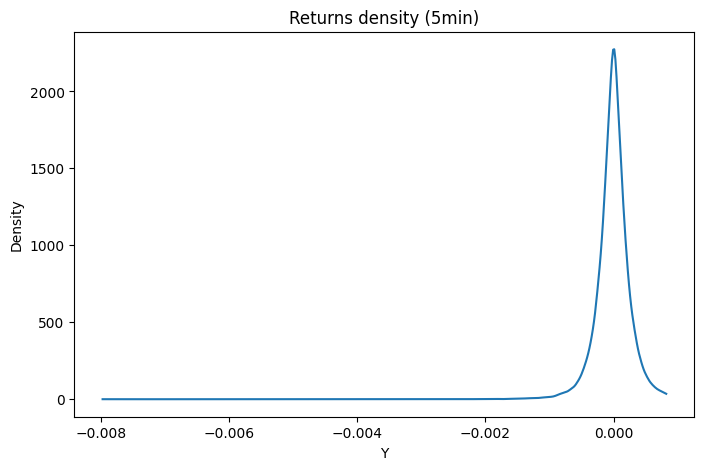

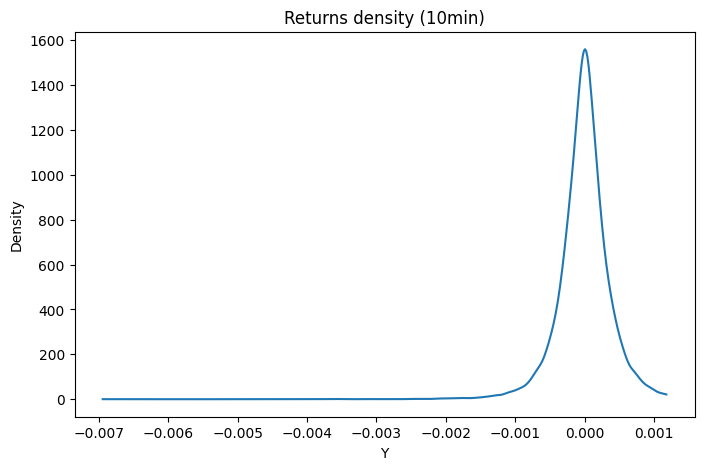

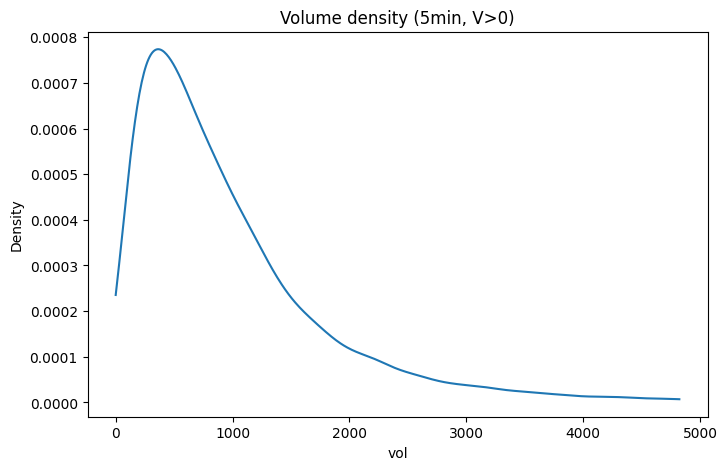

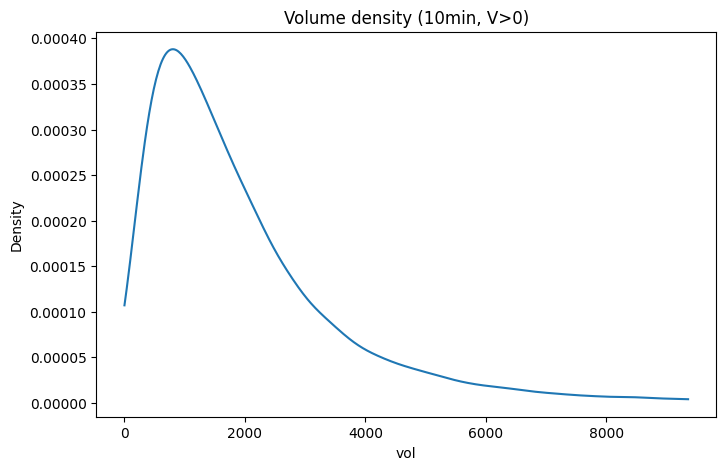

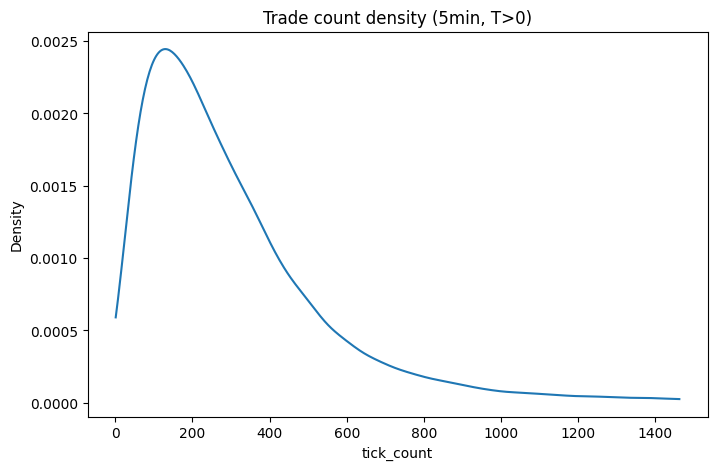

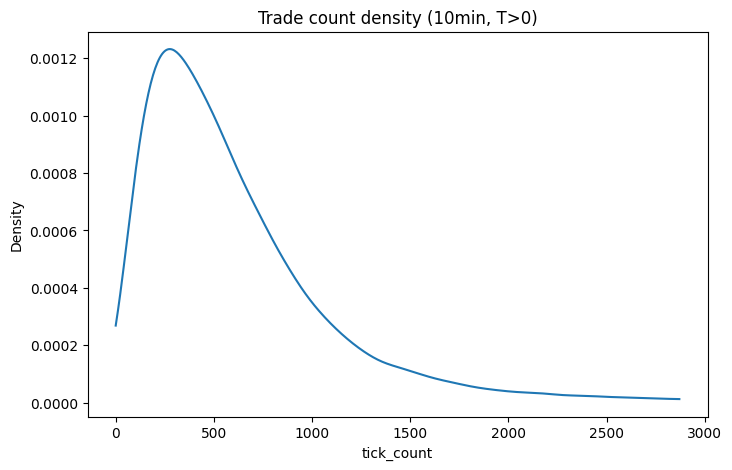

In [29]:
# KDE plots for both resolutions
plot_kde(fivemin_bars['Y'], 'Returns density (5min)')
plot_kde(tenmin_bars['Y'], 'Returns density (10min)')

plot_kde(fivemin_bars['vol'], 'Volume density (5min, V>0)', zero_filter=True)
plot_kde(tenmin_bars['vol'], 'Volume density (10min, V>0)', zero_filter=True)

plot_kde(fivemin_bars['tick_count'], 'Trade count density (5min, T>0)', zero_filter=True)
plot_kde(tenmin_bars['tick_count'], 'Trade count density (10min, T>0)', zero_filter=True)

MODEL III

In [30]:
#identify and report the weekend gaps
time_diffs = raw_ticks.index.to_series().diff()
big_gaps = time_diffs[time_diffs > pd.Timedelta(hours=6)]
print("Number of gaps > 6 hours:", len(big_gaps))
big_gaps.head(10)

Number of gaps > 6 hours: 53


timestamp
2025-01-05 22:00:11.712000+00:00   2 days 00:00:12.278000
2025-01-12 22:03:17.994000+00:00   2 days 00:03:18.774000
2025-01-19 22:01:16.706000+00:00   2 days 00:01:20.332000
2025-01-26 22:00:03.929000+00:00   2 days 00:00:05.198000
2025-02-02 22:00:07.171000+00:00   2 days 00:00:09.853000
2025-02-09 22:00:01.604000+00:00   2 days 00:00:02.018000
2025-02-16 22:00:03.782000+00:00   2 days 00:00:04.547000
2025-02-23 22:02:11.345000+00:00   2 days 00:02:20.796000
2025-03-02 22:00:00.461000+00:00   2 days 00:00:01.609000
2025-03-09 21:00:09.602000+00:00   1 days 23:00:11.901000
Name: timestamp, dtype: timedelta64[ns]

In [31]:
print("Total number of big gaps:", len(big_gaps))
big_gaps.describe()


Total number of big gaps: 53


count                           53
mean     1 days 23:22:32.919792452
std      0 days 04:39:44.734164540
min         0 days 14:06:10.982000
25%         2 days 00:00:05.109000
50%         2 days 00:00:12.395000
75%         2 days 00:01:16.774000
max         2 days 01:00:04.229000
Name: timestamp, dtype: object

In [59]:
#Choose N = ticks per bar
avg_ticks_per_5min = fivemin_bars['tick_count'].mean()
print("Average ticks per 5-min bar:", avg_ticks_per_5min)

Average ticks per 5-min bar: 223.8949271203948


In [33]:
def build_tradecount_bars(raw_ticks_df, N):
    df_reset = raw_ticks_df.reset_index()
    df_reset['bar_id'] = df_reset.index // N
    
    bars = df_reset.groupby('bar_id').agg(
        start_time=('timestamp', 'first'),
        end_time=('timestamp', 'last'),
        open=('mid', 'first'),
        high=('mid', 'max'),
        low=('mid', 'min'),
        close=('mid', 'last'),
        vol=('volume', 'sum'),
        tick_count=('mid', 'count'),
    )
    
    bars['duration'] = bars['end_time'] - bars['start_time']
    bars['Y'] = np.log(bars['close'] / bars['close'].shift(1))
    
    return bars

In [34]:
N_5min = round(fivemin_bars['tick_count'].mean())
N_10min = round(tenmin_bars['tick_count'].mean())
N_1h = round(onehour_bars['tick_count'].mean())
N_6h = round(sixhour_bars['tick_count'].mean())
N_8h = round(eighthour_bars['tick_count'].mean())



print("N for 5-min equivalent:", N_5min)
print("N for 10-min equivalent:", N_10min)

N for 5-min equivalent: 224
N for 10-min equivalent: 448


In [35]:
tradecount_bars_5min = build_tradecount_bars(raw_ticks, N_5min)
tradecount_bars_10min = build_tradecount_bars(raw_ticks, N_10min)
tradecount_bars_1h = build_tradecount_bars(raw_ticks, N_1h)
tradecount_bars_6h = build_tradecount_bars(raw_ticks, N_6h)
tradecount_bars_8h = build_tradecount_bars(raw_ticks, N_8h)



tradecount_bars_5min.shape, tradecount_bars_10min.shape

((104507, 10), (52254, 10))

In [36]:
print(tradecount_bars_5min['duration'].describe())
print()
print(tradecount_bars_10min['duration'].describe())

count                       104507
mean     0 days 00:04:59.182866764
std      0 days 01:04:41.626229858
min         0 days 00:00:14.505000
25%         0 days 00:01:31.147000
50%         0 days 00:02:33.818000
75%         0 days 00:04:15.964500
max         2 days 01:03:27.753000
Name: duration, dtype: object

count                        52254
mean     0 days 00:09:59.313038293
std      0 days 01:31:51.135009090
min         0 days 00:00:31.761000
25%         0 days 00:03:07.605000
50%         0 days 00:05:13.656000
75%         0 days 00:08:38.345750
max         2 days 01:04:14.089000
Name: duration, dtype: object


In [60]:
def clean_tradecount_bars(bars, threshold_hours=6):
    #Flag bars with abnormal duration
    bad_bars = bars['duration'] > pd.Timedelta(hours=threshold_hours)
    print(f"Number of bars excluded (weekend-spanning): {bad_bars.sum()} out of {len(bars)}")
    
    #Also flag the bar AFTER a bad bar, since its return compares across the gap
    bad_bars_next = bad_bars.shift(1, fill_value=False)
    
    cleaned = bars[~bad_bars & ~bad_bars_next].copy()
    return cleaned

tradecount_bars_5min_clean = clean_tradecount_bars(tradecount_bars_5min)
tradecount_bars_10min_clean = clean_tradecount_bars(tradecount_bars_10min)
tradecount_bars_1h_clean = clean_tradecount_bars(tradecount_bars_1h)
tradecount_bars_6h_clean = clean_tradecount_bars(tradecount_bars_6h)
tradecount_bars_8h_clean = clean_tradecount_bars(tradecount_bars_8h)



tradecount_bars_5min_clean.shape, tradecount_bars_10min_clean.shape

Number of bars excluded (weekend-spanning): 53 out of 104507
Number of bars excluded (weekend-spanning): 53 out of 52254
Number of bars excluded (weekend-spanning): 53 out of 8713
Number of bars excluded (weekend-spanning): 354 out of 1454
Number of bars excluded (weekend-spanning): 405 out of 1090


((104401, 10), (52148, 10))

In [62]:
results_comparison = []

results_comparison.append(get_stats(fivemin_bars['Y'], 'Calendar-time Returns (5min)'))
results_comparison.append(get_stats(tradecount_bars_5min_clean['Y'], 'Trade-count Returns (~5min equiv, N=224)'))

results_comparison.append(get_stats(tenmin_bars['Y'], 'Calendar-time Returns (10min)'))
results_comparison.append(get_stats(tradecount_bars_10min_clean['Y'], 'Trade-count Returns (~10min equiv, N=448)'))

results_comparison.append(get_stats(onehour_bars['Y'], 'Calendar-time Returns (1h)'))
results_comparison.append(get_stats(tradecount_bars_1h_clean['Y'], 'Trade-count Returns '))

results_comparison.append(get_stats(sixhour_bars['Y'], 'Calendar-time Returns (6h)'))
results_comparison.append(get_stats(tradecount_bars_6h_clean['Y'], 'Trade-count Returns '))

results_comparison.append(get_stats(eighthour_bars['Y'], 'Calendar-time Returns (8h)'))
results_comparison.append(get_stats(tradecount_bars_8h_clean['Y'], 'Trade-count Returns'))

table_comparison = pd.DataFrame(results_comparison)
table_comparison

,series,mean,variance,m3,m4,m5,m6,skewness,kurtosis
0,Calendar-time Returns (5min),0.000002,9.189119e-08,9.090209e-12,4.532401e-13,1.154913e-15,2.267718e-17,0.326335,53.676055
1,"Trade-count Returns (~5min equiv, N=224)",0.000001,6.556475e-08,2.820211e-13,5.042199e-14,-1.480868e-17,3.804734e-19,0.016799,11.729492
2,Calendar-time Returns (10min),0.000004,1.805830e-07,3.107532e-11,9.564919e-13,3.061902e-15,4.299840e-17,0.404949,29.331064
3,"Trade-count Returns (~10min equiv, N=448)",0.000003,1.326803e-07,-2.002109e-12,2.198007e-13,-2.958685e-16,3.984222e-18,-0.041426,12.485786
4,Calendar-time Returns (1h),0.000024,9.979026e-07,5.819898e-10,1.648630e-11,5.879027e-14,1.157410e-15,0.583826,16.555679
5,Trade-count Returns,0.000016,7.589084e-07,-7.000498e-11,3.855351e-12,-4.740545e-15,8.430248e-17,-0.105888,6.693991
6,Calendar-time Returns (6h),0.000129,5.850482e-06,6.793392e-09,2.304107e-10,9.927792e-13,2.030254e-14,0.480064,6.731616
7,Trade-count Returns,0.000109,5.148576e-06,1.981535e-09,1.201285e-10,2.736944e-13,7.309354e-15,0.169618,4.531811
8,Calendar-time Returns (8h),0.000172,7.074227e-06,8.279311e-09,3.069372e-10,1.241513e-12,2.968157e-14,0.440023,6.133263
9,Trade-count Returns,0.000070,7.931222e-06,2.118096e-09,2.526212e-10,1.420507e-13,1.562407e-14,0.094828,4.015962


T distribution trial

In [45]:
from scipy.stats import t as t_dist

def fit_and_plot_with_t(series, title, ax):
    s = series.dropna()
    n = len(s)
    sigma = s.std()
    h = sigma * (4/3)**(1/5) * n**(-1/5)
    bw_factor = h / sigma
    
    upper = s.quantile(0.995)
    lower = s.quantile(0.005)
    x_range = np.linspace(lower, upper, 500)
    density = gaussian_kde(s, bw_method=bw_factor)(x_range)
    
    mu = s.mean()
    normal_curve = norm.pdf(x_range, mu, sigma)
    
    # Fit Student's t via MLE
    t_params = t_dist.fit(s)  # returns (df, loc, scale)
    t_curve = t_dist.pdf(x_range, *t_params)
    
    ax.plot(x_range, density, label='KDE estimate', linewidth=2)
    ax.plot(x_range, normal_curve, label='Normal', linestyle='--')
    ax.plot(x_range, t_curve, label=f't-dist (df={t_params[0]:.1f})', linestyle=':')
    ax.set_title(title)
    ax.set_xlabel('Return')
    ax.set_ylabel('Density')
    ax.legend()
    
    return t_params

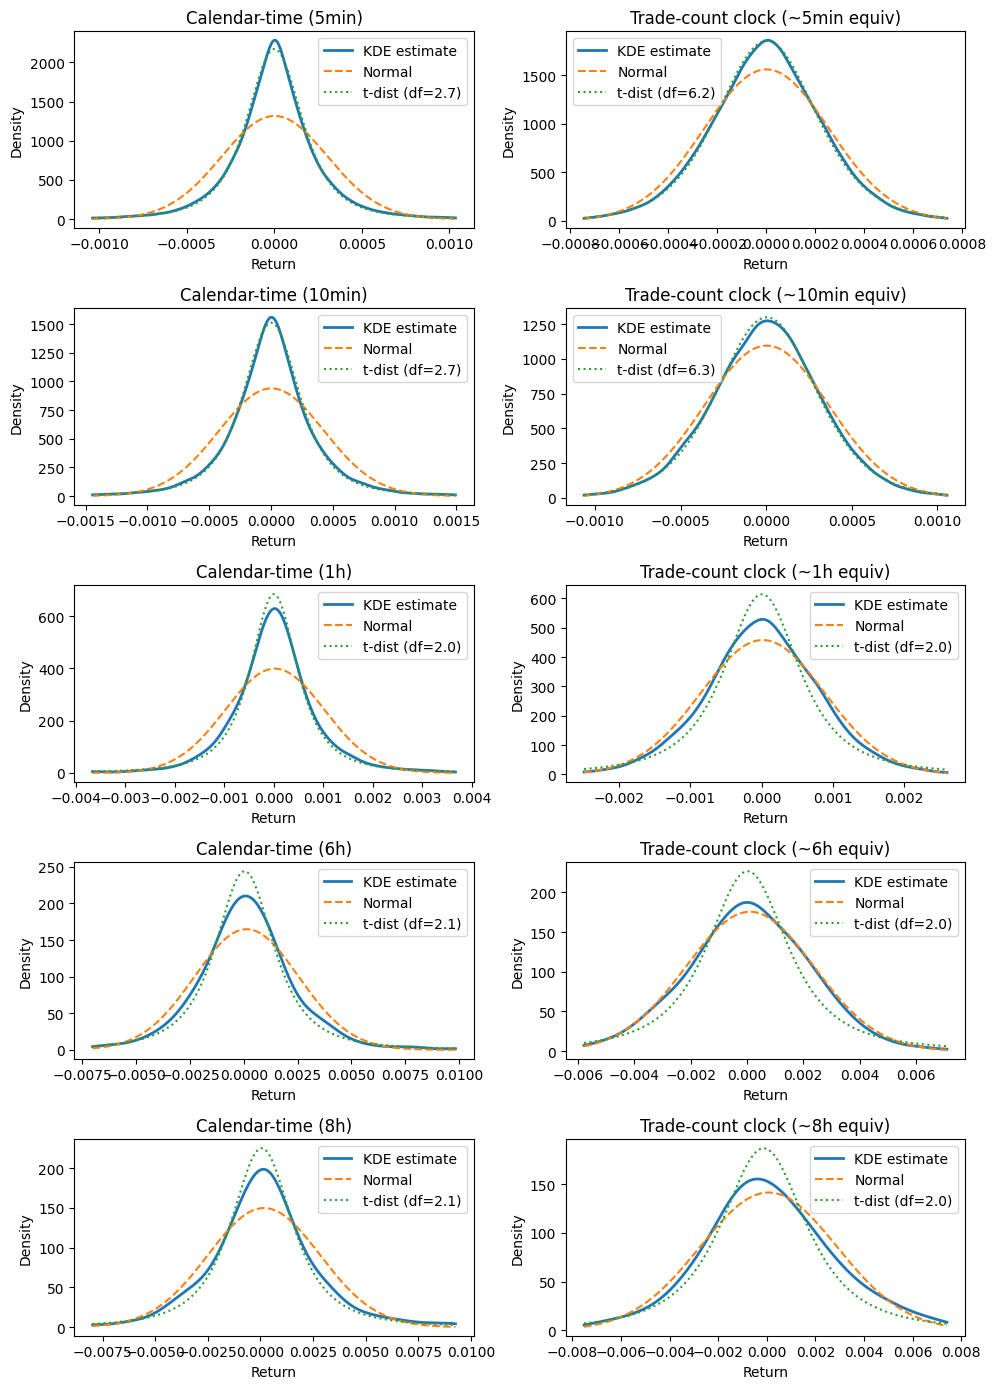

Calendar-time (5min): df=2.66
Calendar-time (10min): df=2.71
Calendar-time (1h): df=1.99
Calendar-time (6h): df=2.10
Calendar-time (8h): df=2.09
Trade-count clock (~5min equiv): df=6.20
Trade-count clock (~10min equiv): df=6.27
Trade-count clock (~1h equiv): df=1.99
Trade-count clock (~6h equiv): df=1.98
Trade-count clock (~8h equiv): df=2.04


In [66]:
fig, axes = plt.subplots(5,2, figsize=(10, 14))

series_list = [
    (fivemin_bars['Y'], 'Calendar-time (5min)', axes[0,0]),
    (tenmin_bars['Y'], 'Calendar-time (10min)', axes[1,0]),
    (onehour_bars['Y'], 'Calendar-time (1h)', axes[2,0]),
    (sixhour_bars['Y'], 'Calendar-time (6h)', axes[3,0]),
    (eighthour_bars['Y'], 'Calendar-time (8h)', axes[4,0]),


    (tradecount_bars_5min_clean['Y'], 'Trade-count clock (~5min equiv)', axes[0,1]),
    (tradecount_bars_10min_clean['Y'], 'Trade-count clock (~10min equiv)', axes[1,1]),
    (tradecount_bars_1h_clean['Y'], 'Trade-count clock (~1h equiv)', axes[2,1]),
    (tradecount_bars_6h_clean['Y'], 'Trade-count clock (~6h equiv)', axes[3,1]),
    (tradecount_bars_8h_clean['Y'], 'Trade-count clock (~8h equiv)', axes[4,1]),


]

fitted_params = {}

for series, title, ax in series_list:
    params = fit_and_plot_with_t(series, title, ax)
    fitted_params[title] = params

plt.tight_layout()
plt.show()

for title, params in fitted_params.items():
    print(f"{title}: df={params[0]:.2f}")